In [1]:
from Montreal_UHI_toolbox import *

In [18]:
is_urban_station = blurred_urban_fraction > 0.5
is_rural_station = blurred_urban_fraction < 0.01

station_rotated_points = rotated_pole.transform_points(ccrs.PlateCarree(), stations['lon'].values, stations['lat'].values)
station_rlon = station_rotated_points[:, 0]
station_rlat = station_rotated_points[:, 1]

urban_station_mask = is_urban_station.sel(
    rlat=xr.DataArray(station_rlat, dims='points'),
    rlon=xr.DataArray(station_rlon, dims='points'),
    method='nearest'
).values

rural_station_mask =  is_rural_station.sel(
    rlat=xr.DataArray(station_rlat, dims='points'),
    rlon=xr.DataArray(station_rlon, dims='points'),
    method='nearest'
).values

station_urban_fraction = blurred_urban_fraction.sel(
    rlat=xr.DataArray(station_rlat, dims='points'),
    rlon=xr.DataArray(station_rlon, dims='points'),
    method='nearest'
).values

stations = stations.assign_coords(is_urban_station=('station',urban_station_mask),
                                  is_rural_station=('station',rural_station_mask),
                                  station_urban_fraction=('station',station_urban_fraction))

urban_stations = stations.where(stations.is_urban_station, drop=True)
rural_stations = stations.where(stations.is_rural_station, drop=True)
subur_stations = stations.where(stations.is_rural_station==stations.is_urban_station, drop=True)

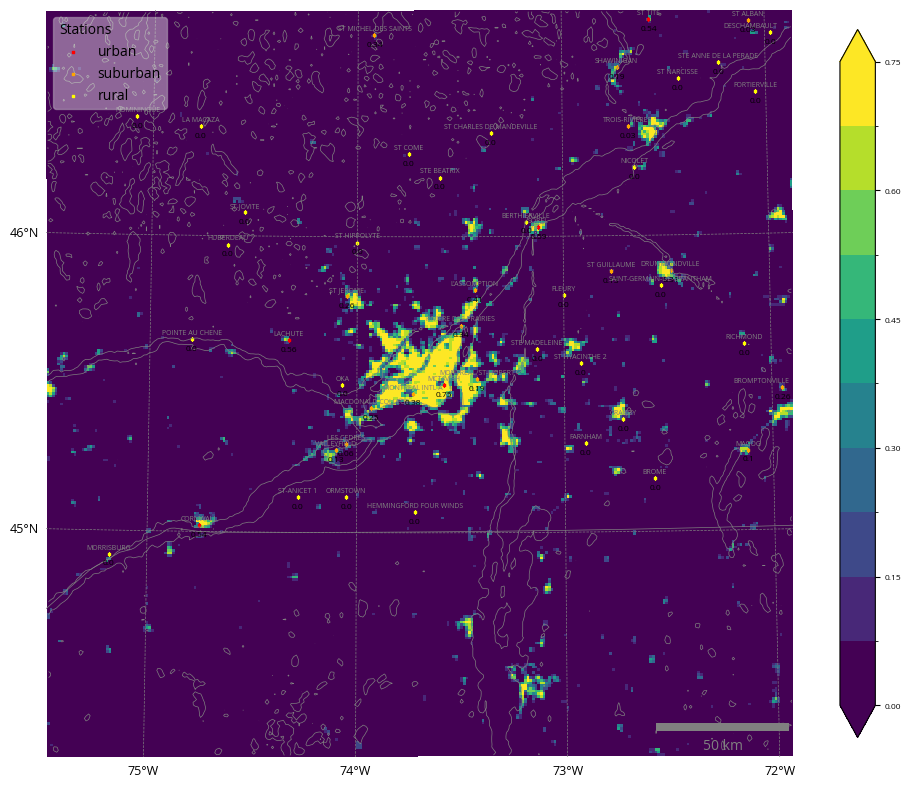

In [19]:
fig,ax,cb = plot_field(blurred_urban_fraction)
plot_stations(fig,ax,field=blurred_urban_fraction)
ax.scatter(urban_stations.lon, urban_stations.lat, transform=ccrs.PlateCarree(),
           color='red', marker='s',label='urban',s=3)
ax.scatter(subur_stations.lon, subur_stations.lat, transform=ccrs.PlateCarree(),
           color='orange', marker='s',label='suburban',s=3)
ax.scatter(rural_stations.lon, rural_stations.lat, transform=ccrs.PlateCarree(),
           color='yellow', marker='s',label='rural',s=3)
ax.legend(title='Stations',alignment='left',framealpha=0.4)
# plt.savefig('blurred_urban_fraction.pdf')